In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [56]:
df=pd.read_csv("data.csv")
df

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,...,5,3,2,7,8,2,4,5,3,High
996,996,P996,37,2,6,8,7,7,7,6,...,9,6,5,7,2,4,3,1,4,High
997,997,P997,25,2,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
998,998,P998,18,2,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [57]:
df.drop(df.columns[[0,1]], axis=1, inplace=True)

In [58]:
df

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,44,1,6,7,7,7,7,6,7,7,...,5,3,2,7,8,2,4,5,3,High
996,37,2,6,8,7,7,7,6,7,7,...,9,6,5,7,2,4,3,1,4,High
997,25,2,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
998,18,2,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


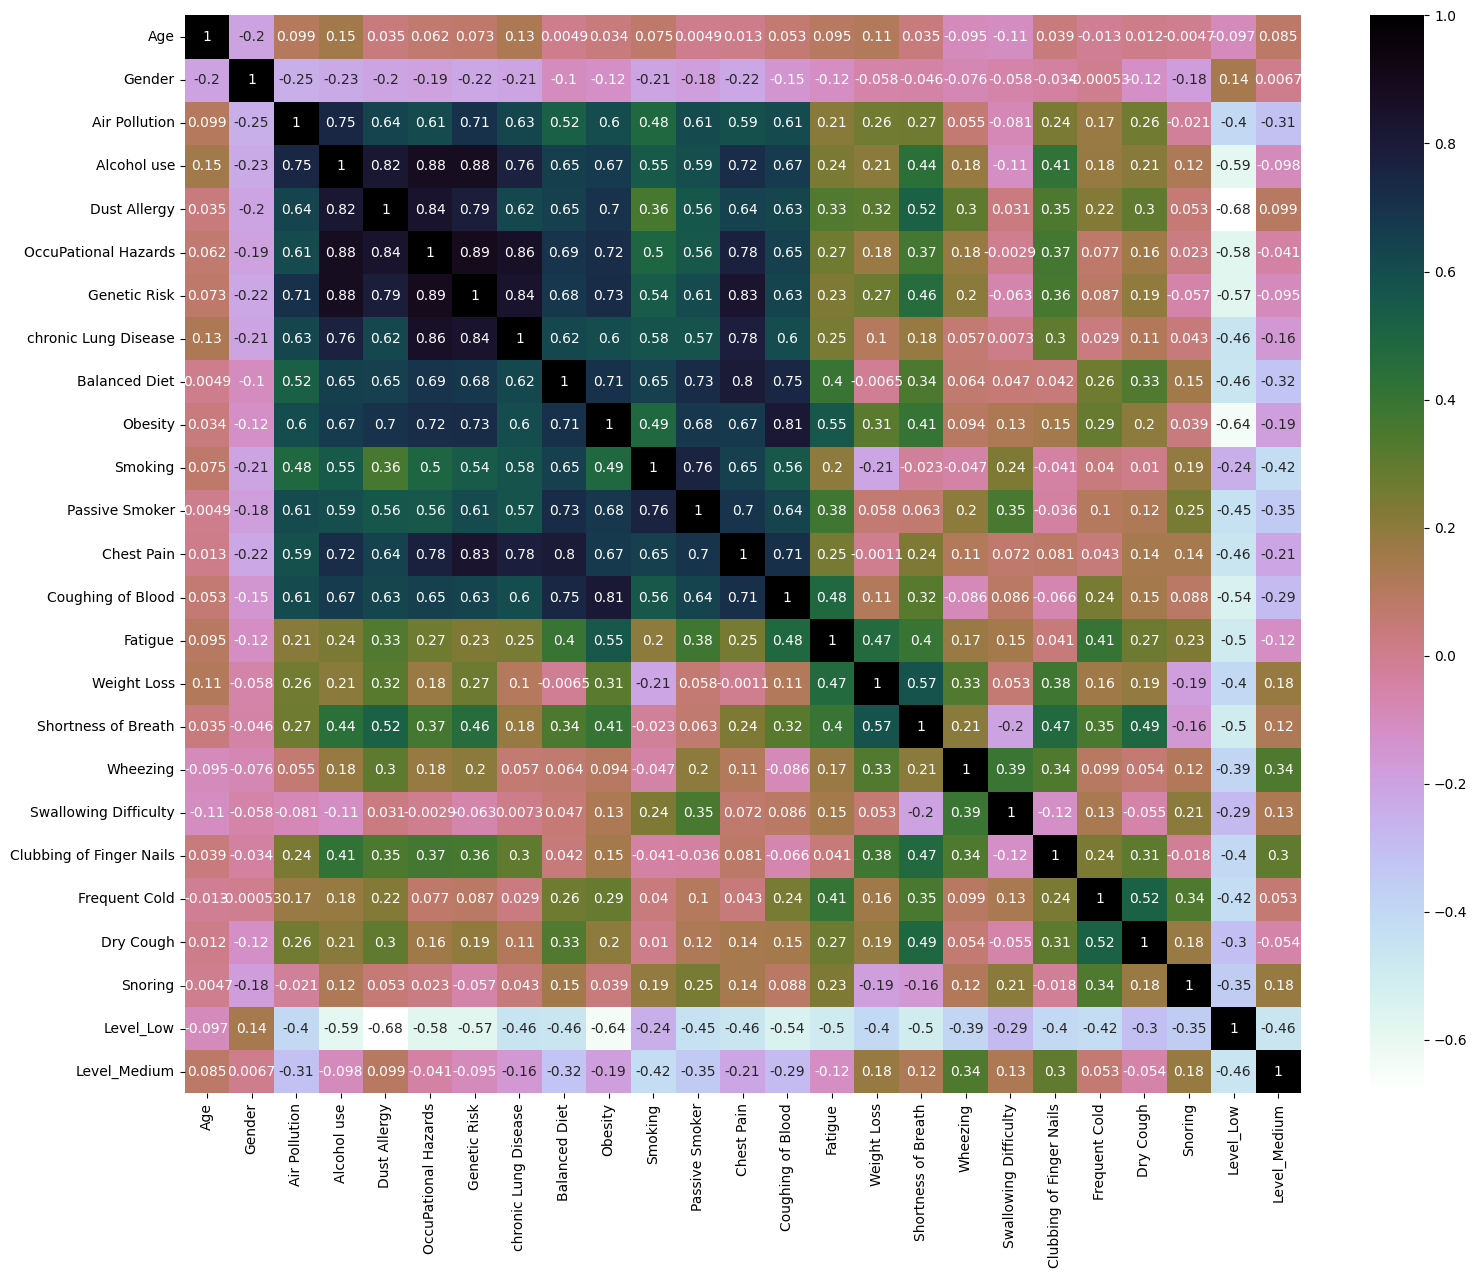

In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(18,14))
sns.heatmap(df_encoded.corr(), annot=True, cmap='cubehelix_r')
plt.show()


In [12]:
df.columns

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Level'],
      dtype='object')

C:\Users\Acer\AppData\Local\Temp\ipykernel_6680\2746520522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df,palette=mag)


<Axes: xlabel='Gender', ylabel='count'>

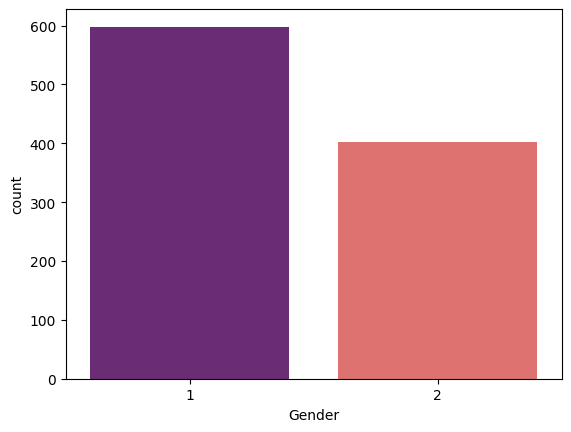

In [13]:
mag="magma"
sns.countplot(x="Gender", data=df,palette=mag)

<Axes: xlabel='Level', ylabel='count'>

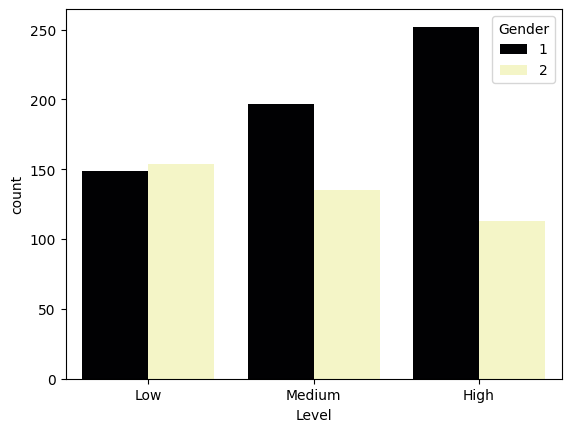

In [14]:
sns.countplot(x="Level",data=df,hue="Gender",palette=mag)

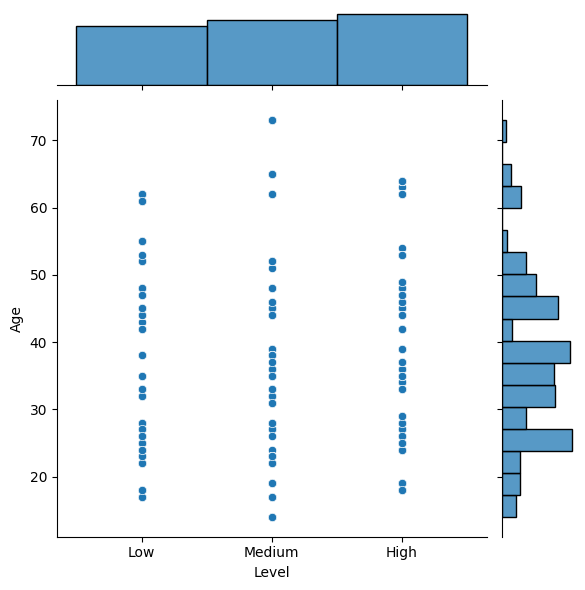

In [15]:
sns.jointplot(x="Level",y="Age",data=df,kind='scatter')

In [16]:
df["Obesity"].value_counts()

Obesity
7    356
3    193
4    191
2    140
1     70
6     30
5     20
Name: count, dtype: int64

<Axes: xlabel='Level', ylabel='count'>

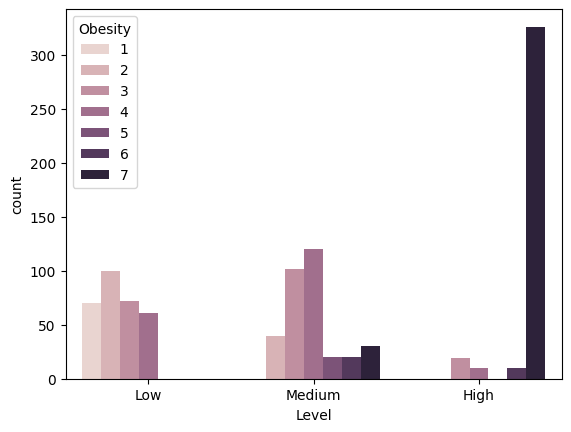

In [17]:
sns.countplot(x="Level",hue="Obesity",data=df)

In [18]:
sns.set(rc={'figure.figsize':(9,6.27)})

In [19]:

#Train Test Split


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [92]:
X = df.drop(columns='Level', axis=1)
Y = df['Level']

In [93]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [94]:
print(X.shape, X_train.shape, X_test.shape)

(1000, 23) (800, 23) (200, 23)


In [96]:
#Dropping one of any Highly CO related Values

In [100]:
def correlation(dataset, threshold):
    col_corr = set()  
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i] 
                col_corr.add(colname)
    return col_corr

corr_features = correlation(X_train, 0.80)
len(set(corr_features))

0

In [101]:
corr_features

set()

In [102]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [103]:
train_data=Y_test
train_data
train_data.to_csv("testy.csv")

In [104]:
train_data.columns

AttributeError: 'Series' object has no attribute 'columns'

In [105]:
#Logistic Regression Model


In [106]:
model = LogisticRegression()

In [107]:
model.fit(X_train, Y_train)

C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [110]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data:', training_data_accuracy*100)

Accuracy score of the training data: 98.375


In [111]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data:', test_data_accuracy*100)

Accuracy score of the test data: 95.5


In [117]:
input_data = (62,1,6,8,7,7,8,7,3,2,4,1,4,2,4,2,3)
input_data_as_numpy_arrays=np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = model.predict(input_data_reshaped)
print(prediction)
if (prediction[0]==0):
    print('the person does not lung cancer')
else:
    print('The person has Lung Cancer Disease')

['High']
The person has Lung Cancer Disease


C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [118]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,X_test_prediction))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       0.89      0.97      0.93        61
      Medium       0.97      0.89      0.93        66

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



<Axes: >

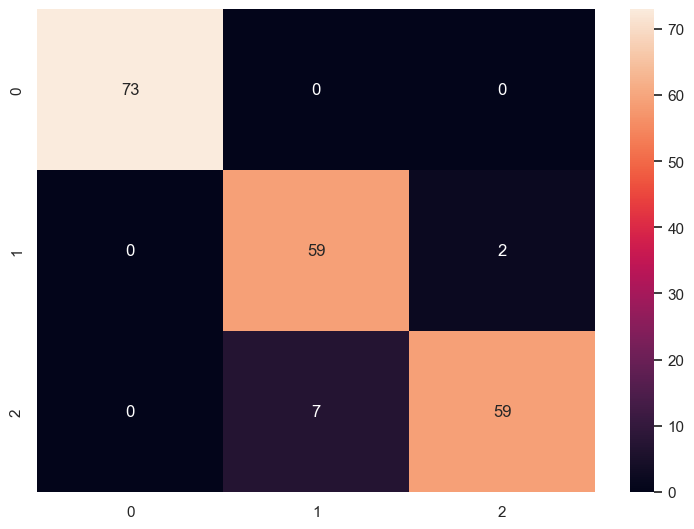

In [122]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True)

In [123]:
from sklearn import svm
from sklearn import metrics

In [125]:
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)
prediction_svm=classifier.predict(X_test)
print('The accuracy of the SVM is:', metrics.accuracy_score(prediction_svm, Y_test))

The accuracy of the SVM is: 1.0


In [126]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction_svm))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [127]:
from sklearn.tree import DecisionTreeClassifier

In [128]:
dis_tree=DecisionTreeClassifier()
dis_tree.fit(X_train,Y_train)
prediction_dis=dis_tree.predict(X_test)
print('The accuracy of Decision Tree is:', metrics.accuracy_score(prediction_dis, Y_test))

The accuracy of Decision Tree is: 1.0


In [129]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction_dis))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [130]:
from sklearn.neighbors import KNeighborsClassifier

In [131]:
dis_tree = DecisionTreeClassifier()
dis_tree.fit(X_train, Y_train)
prediction_dis = dis_tree.predict(X_test)
print('The accuracy of Decision Tree is: ', metrics.accuracy_score(prediction_dis, Y_test))

The accuracy of Decision Tree is:  1.0


In [132]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction_dis))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [133]:
from sklearn.neighbors import KNeighborsClassifier

In [134]:
knn_m = KNeighborsClassifier(n_neighbors=3) 
knn_m.fit(X_train, Y_train)
prediction1 = knn_m.predict(X_test)
print('The accuracy of KNN is: ', metrics.accuracy_score(prediction1, Y_test))

The accuracy of KNN is:  1.0


In [135]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction1))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [136]:
prediction1

array(['Medium', 'Low', 'Medium', 'High', 'Low', 'High', 'High', 'Medium',
       'High', 'High', 'High', 'Medium', 'Low', 'High', 'High', 'Medium',
       'Low', 'Medium', 'High', 'High', 'High', 'High', 'High', 'Medium',
       'Low', 'High', 'High', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'High', 'Medium', 'Low', 'Low', 'Low', 'Low', 'High',
       'High', 'Medium', 'Low', 'Low', 'High', 'Medium', 'High', 'Low',
       'High', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'High',
       'Medium', 'High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High',
       'Medium', 'Medium', 'Medium', 'Low', 'Low', 'Medium', 'High',
       'Low', 'Low', 'Medium', 'Medium', 'High', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Low', 'High', 'Medium', 'Low',
       'Low', 'Low', 'Low', 'High', 'High', 'Low', 'Medium', 'Low',
       'Medium', 'High', 'Low', 'Medium', 'High', 'High', 'High', 'High',
       'Low', 'Medium', 'Medium', 'Medium', 'High', 'Low'

In [137]:
display(pd.DataFrame({"Predicted":prediction1,"Actual":Y_test}))

,Predicted,Actual
402,Medium,Medium
811,Low,Low
515,Medium,Medium
344,High,High
825,Low,Low
...,...,...
233,High,High
405,Medium,Medium
698,Medium,Medium
526,Medium,Medium


<Axes: >

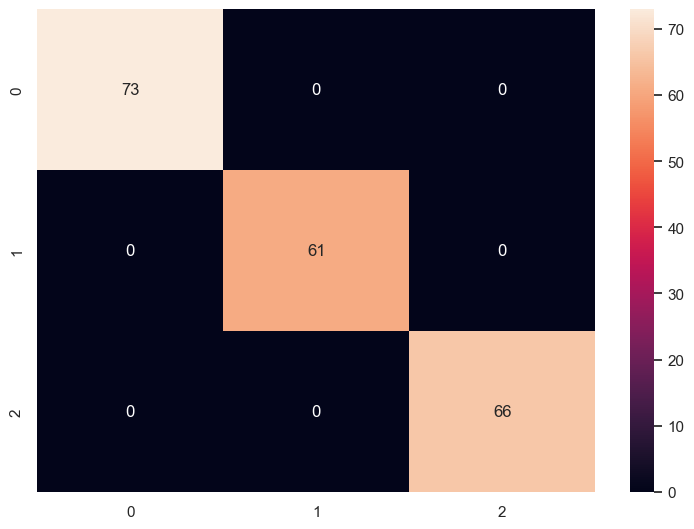

In [138]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(Y_test, prediction1) 
sns.heatmap(cm, annot=True)

In [139]:
print('The accuracy of the Logistic Regression is: ', metrics.accuracy_score(X_test_prediction, Y_test))
print('The accuracy of the SVM is: ', metrics.accuracy_score(prediction_svm, Y_test))
print('The accuracy of Decision Tree is: ', metrics.accuracy_score(prediction_dis, Y_test))
print('The accuracy of KNN is: ', metrics.accuracy_score(prediction1, Y_test))

The accuracy of the Logistic Regression is:  0.955
The accuracy of the SVM is:  1.0
The accuracy of Decision Tree is:  1.0
The accuracy of KNN is:  1.0


In [140]:
import pickle
filename = "final_model.sav"
pickle.dump(classifier , open(filename,'wb'))